In [3]:
# Import All the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv("Loan.csv")
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [5]:
#Handling Missing data
category_columns = df.select_dtypes(include=['object']).columns  
numeric_columns = df.select_dtypes(include=['float64' ,'int64']).columns 

C:\Users\Hp\AppData\Local\Temp\ipykernel_12700\350190054.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  category_columns = df.select_dtypes(include=['object']).columns


In [6]:
numeric_columns.size + category_columns.size

20

In [7]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy='mean')
df[numeric_columns] = num_imp.fit_transform(df[numeric_columns])


In [8]:
cat_imp = SimpleImputer(strategy='most_frequent')
df[category_columns] = cat_imp.fit_transform(df[category_columns])

In [9]:
df.head()
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

In [10]:
# EDA Exploratory Data analysis

Text(0.5, 1.0, 'Is loan approved or not ?')

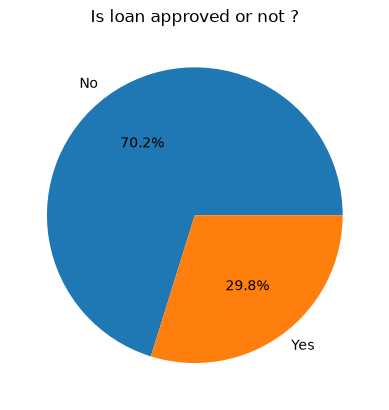

In [11]:
# how balanced our classes are?
classes_count = df["Loan_Approved"].value_counts()
plt.pie(classes_count, labels=["No","Yes"], autopct="%1.1f%%")
plt.title('Is loan approved or not ?')

[Text(0, 0, '252'),
 Text(0, 0, '199'),
 Text(0, 0, '190'),
 Text(0, 0, '181'),
 Text(0, 0, '178')]

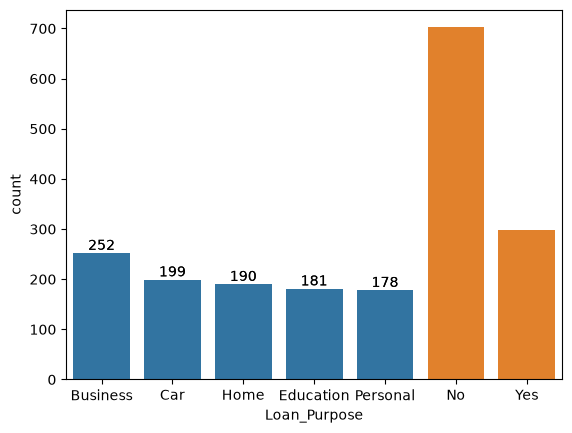

In [17]:
# Analyze categorical
import seaborn as sns

# gender_count = df["Gender"].value_counts()
# ax = sns.barplot(gender_count)
# ax.bar_label(ax.containers[0])

#merital status
# met_count = df["Marital_Status"].value_counts()
# ax = sns.barplot(met_count)
# ax.bar_label(ax.containers[0])

# 


# Loan approve or not (analize)
# Loan_aprv_count = df["Loan_Approved"].value_counts()
# ax = sns.barplot(Loan_aprv_count)
# ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

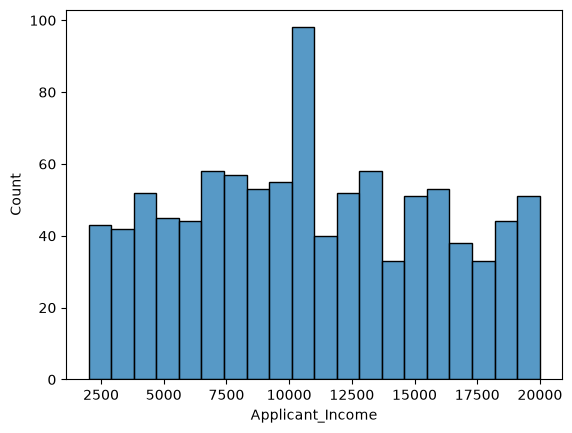

In [18]:
# analyze Income 
sns.histplot(
    data=df,
    x="Applicant_Income",
    bins=20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

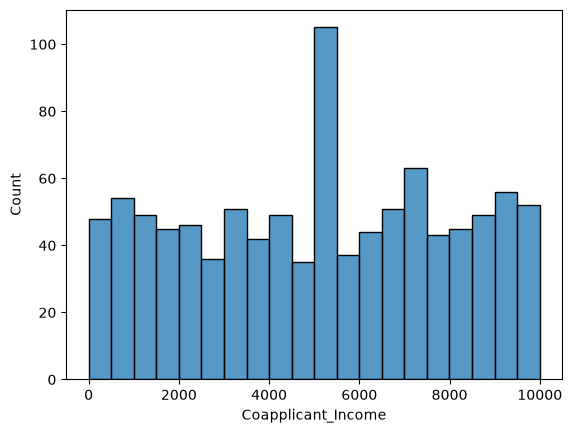

In [20]:
sns.histplot(
    data=df,
    x="Coapplicant_Income",
    bins=20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

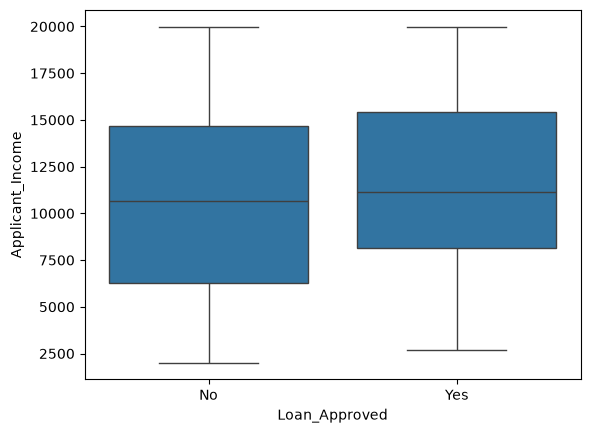

In [21]:
# outliers - box plot

sns.boxplot(
    data=df,
    x='Loan_Approved',
    y="Applicant_Income"
)

<Axes: xlabel='Loan_Approved', ylabel='Savings'>

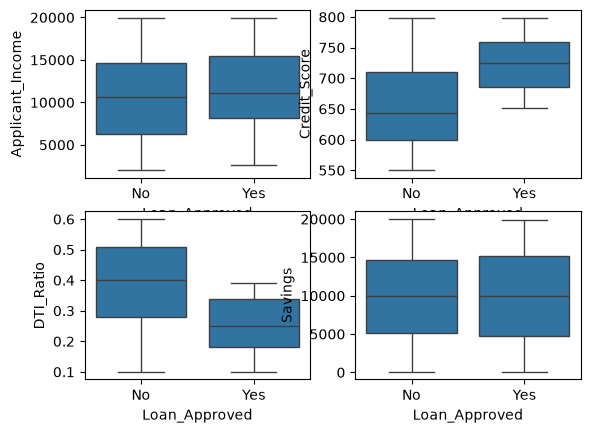

In [25]:
fig , axes = plt.subplots(2, 2)
sns.boxplot( ax=axes[0,0], data=df, x='Loan_Approved', y="Applicant_Income")
sns.boxplot( ax=axes[0,1], data=df, x='Loan_Approved', y="Credit_Score")
sns.boxplot( ax=axes[1,0], data=df, x='Loan_Approved', y="DTI_Ratio")
sns.boxplot( ax=axes[1,1], data=df, x='Loan_Approved', y="Savings")

<Axes: xlabel='Credit_Score', ylabel='Count'>

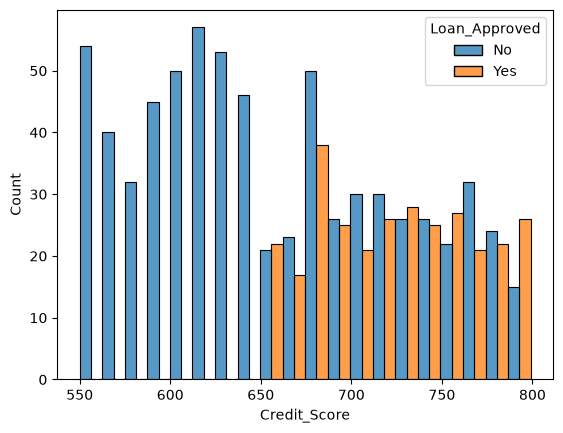

In [31]:
# credit score with loan Approval

sns.histplot(
    data=df,
    x='Credit_Score',
    bins=20,
    hue='Loan_Approved',
    multiple='dodge'
)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

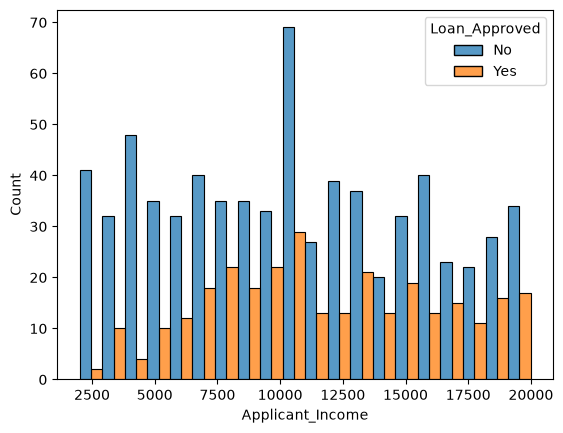

In [32]:

sns.histplot(
    data=df,
    x='Applicant_Income',
    bins=20,
    hue='Loan_Approved',
    multiple='dodge'
)

In [33]:
# Removed Applicant_Id
df = df.drop('Applicant_ID', axis=1)

In [ ]:
#Encodeng 

In [37]:
df.head()
df.columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   str    
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   str    
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   str    
 14  Property_Area       1000 non-null   str    
 15  Education_Level     1000 non-null   str    
 16  Gender            

In [40]:
from sklearn.preprocessing import LabelEncoder , OneHotEncoder
le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df['Loan_Approved'])
df

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.000000,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.000000,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.000000,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.000000,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.000000,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10852.571579,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0,Personal,Urban,1,Male,Unemployed,0
996,3279.000000,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0,Business,Urban,0,Female,Government,0
997,15192.000000,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0,Home,Rural,0,Male,MNC,0
998,9083.000000,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0,Personal,Urban,0,Male,Private,1


In [60]:
# cols = ['Employment_Status', 'Marital_Status', "Loan_Purpose", "Property_Area", "Gender", "Employer_Category"]

# ohe = OneHotEncoder(drop='first', sparse_output=False , handle_unknown='ignore')
# oh_encode = ohe.fit_transform(df[cols])

# encoded_df = pd.DataFrame(oh_encode , columns=ohe.get_feature_names_out(cols), index=df.index)


In [61]:
#Append encoded data to real dataframe
df.head()
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved                   

<Axes: >

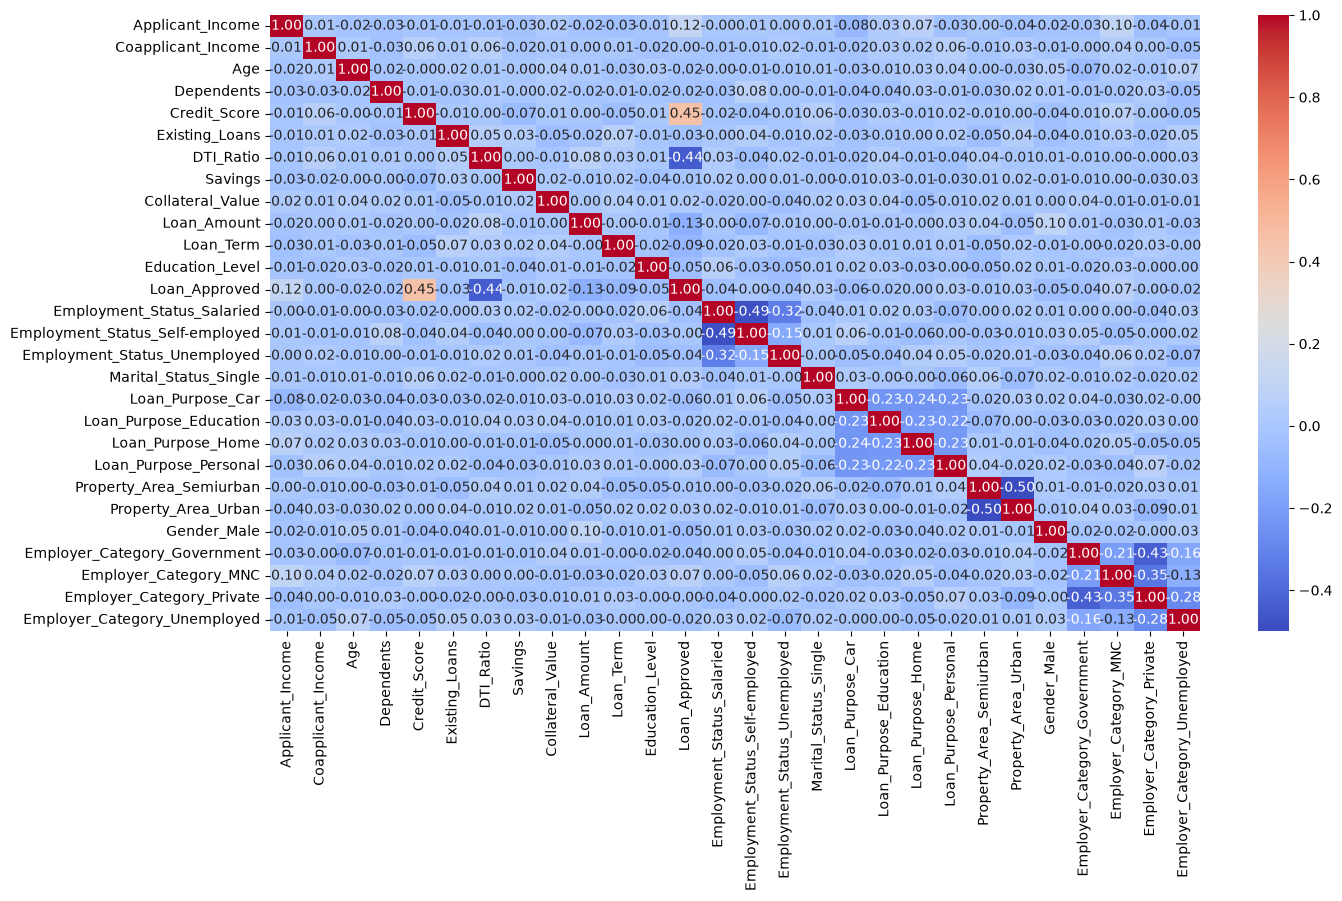

In [65]:
# Correletion and heatmap
num_col = df.select_dtypes(include='number')
corr_metrix = num_col.corr()

# Heatmap
plt.figure(figsize=(15,8))
sns.heatmap(
    corr_metrix,
    annot=True,
    fmt='.2f',
    cmap="coolwarm"
)

In [ ]:
#Train test split and feature selecting

In [67]:
X = df.drop("Loan_Approved" , axis=True)
y = df["Loan_Approved"]

In [68]:
X.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
